# Exploratory Data Analysis - Typhoon Impact Data
## Analysis of Data Properties and Tropical Cyclone Distribution

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (1776, 30)

Columns: ['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality', 'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing', 'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station', 'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END', 'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type', 'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa', 'Weather_Station_Mapped', 'Weather_Records_Found', 'Weather_Days_Covered']


## 1. Basic Data Properties

In [4]:
# Display basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Total Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

DATASET OVERVIEW
Total Records: 2,596
Total Features: 30



Memory Usage: 1.71 MB

First few rows:


,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [5]:
# Data types and missing values
print("\n" + "=" * 80)
print("DATA TYPES AND MISSING VALUES")
print("=" * 80)

info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

print(info_df)

# Visualize missing data
if info_df['Missing Count'].sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = info_df[info_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    plt.barh(missing_cols.index, missing_cols['Missing Count'])
    plt.xlabel('Number of Missing Values')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")


DATA TYPES AND MISSING VALUES
                        Data Type  Missing Count  Missing %  Unique Values
Typhoon Name               object              0        0.0             25
Year                        int64              0        0.0              4
Region                      int64              0        0.0              4
Province                   object              0        0.0             24
City/Municipality          object              0        0.0            442
Families                    int64              0        0.0            882
Person                      int64              0        0.0           1166
Brgy                        int64              0        0.0             60
Dead                        int64              0        0.0              7
Injured/Ill                 int64              0        0.0             21
Missing                     int64              0        0.0              3
Totally                     int64              0        0.0          

## 2. Tropical Cyclone Distribution Analysis

In [6]:
# Analyze typhoon name distribution
print("\n" + "=" * 80)
print("TROPICAL CYCLONE DISTRIBUTION")
print("=" * 80)

typhoon_counts = df['Typhoon Name'].value_counts()
print(f"\nTotal Unique Typhoons: {len(typhoon_counts)}")
print(f"\nRecords per Typhoon:")
print(typhoon_counts)

# Statistical summary
print(f"\nStatistical Summary:")
print(f"  Mean records per typhoon: {typhoon_counts.mean():.2f}")
print(f"  Median records per typhoon: {typhoon_counts.median():.2f}")
print(f"  Std Dev: {typhoon_counts.std():.2f}")
print(f"  Min: {typhoon_counts.min()}")
print(f"  Max: {typhoon_counts.max()}")


TROPICAL CYCLONE DISTRIBUTION

Total Unique Typhoons: 25

Records per Typhoon:
Typhoon Name
PAENG      413
ROLLY      201
KARDING    173
AMBO       161
QUINTA     143
DANTE      133
JOLINA      85
ODETTE      80
BETTY       71
NENENG      71
MAYMAY      71
FLORITA     71
MARING      71
JENNY       71
KIKO        71
HENRY       71
OBET        71
OFEL        71
PEPITO      71
FABIAN      71
DODONG      71
AGATON      71
AMANG       71
ESTER       71
KABAYAN     71
Name: count, dtype: int64

Statistical Summary:
  Mean records per typhoon: 103.84
  Median records per typhoon: 71.00
  Std Dev: 74.92
  Min: 71
  Max: 413


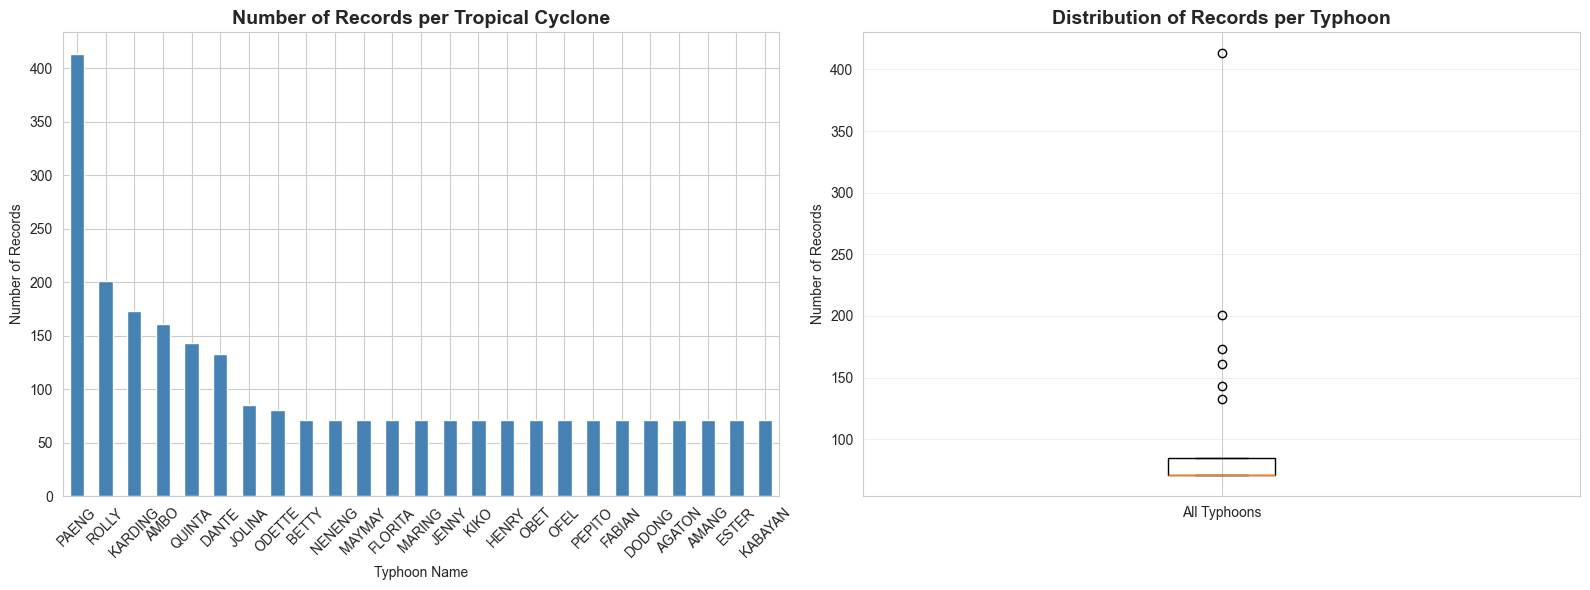

In [7]:
# Visualize typhoon distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
typhoon_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Records per Tropical Cyclone', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Typhoon Name')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=45)

# Box plot
axes[1].boxplot([typhoon_counts.values], vert=True)
axes[1].set_title('Distribution of Records per Typhoon', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Records')
axes[1].set_xticklabels(['All Typhoons'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


CLASS IMBALANCE ANALYSIS

Imbalance Ratio: 5.82:1
  (Max records: 413 vs Min records: 71)

Percentage Distribution:
  PAENG: 15.91%
  ROLLY: 7.74%
  KARDING: 6.66%
  AMBO: 6.2%
  QUINTA: 5.51%
  DANTE: 5.12%
  JOLINA: 3.27%
  ODETTE: 3.08%
  BETTY: 2.73%
  NENENG: 2.73%
  MAYMAY: 2.73%
  FLORITA: 2.73%
  MARING: 2.73%
  JENNY: 2.73%
  KIKO: 2.73%
  HENRY: 2.73%
  OBET: 2.73%
  OFEL: 2.73%
  PEPITO: 2.73%
  FABIAN: 2.73%
  DODONG: 2.73%
  AGATON: 2.73%
  AMANG: 2.73%
  ESTER: 2.73%
  KABAYAN: 2.73%


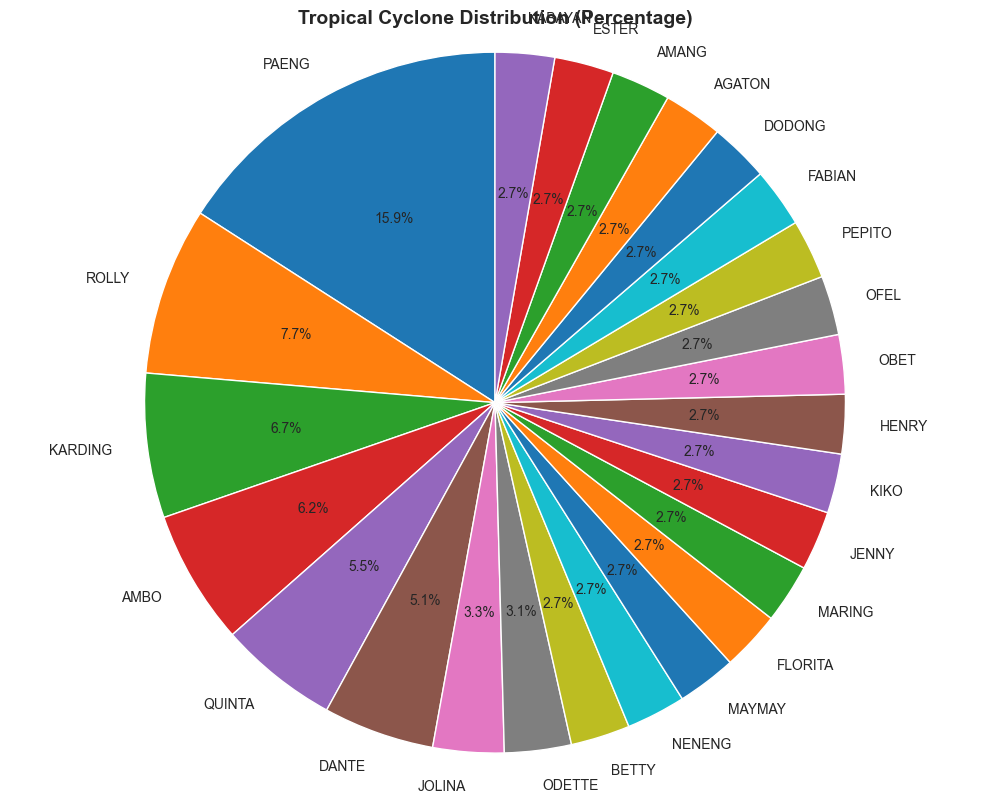


⚠️ CAUTION: Moderate class imbalance detected.
   May affect model performance.


In [8]:
# Check for class imbalance
print("\n" + "=" * 80)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 80)

# Calculate imbalance ratio
max_count = typhoon_counts.max()
min_count = typhoon_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"  (Max records: {max_count} vs Min records: {min_count})")

# Percentage distribution
typhoon_pct = (typhoon_counts / len(df) * 100).round(2)
print(f"\nPercentage Distribution:")
for name, pct in typhoon_pct.items():
    print(f"  {name}: {pct}%")

# Visualize percentage distribution
plt.figure(figsize=(10, 8))
plt.pie(typhoon_counts, labels=typhoon_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Tropical Cyclone Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Assess imbalance severity
if imbalance_ratio > 10:
    print("\n⚠️ WARNING: Severe class imbalance detected!")
    print("   Consider using sampling techniques or class weights.")
elif imbalance_ratio > 3:
    print("\n⚠️ CAUTION: Moderate class imbalance detected.")
    print("   May affect model performance.")
else:
    print("\n✓ Class distribution is relatively balanced.")

## 3. Typhoon Type Distribution


TYPHOON TYPE ANALYSIS

Typhoon Types Distribution:
Typhoon_Type
TY     673
STY    667
STS    555
TD     355
TS     346
Name: count, dtype: int64

Percentage:
Typhoon_Type
TY     25.92
STY    25.69
STS    21.38
TD     13.67
TS     13.33
Name: count, dtype: float64


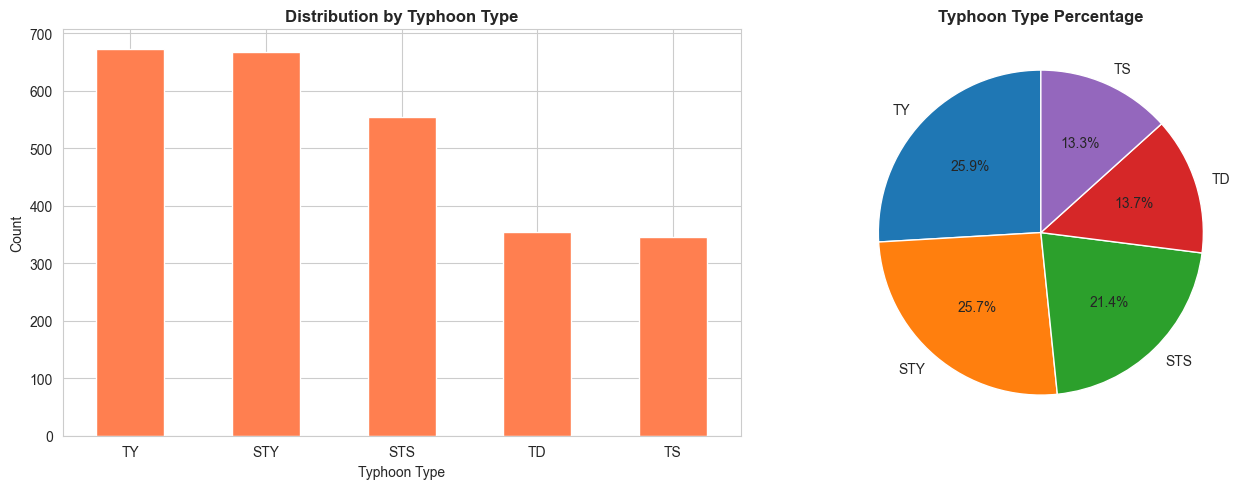

In [9]:
# Analyze typhoon type distribution
print("\n" + "=" * 80)
print("TYPHOON TYPE ANALYSIS")
print("=" * 80)

type_counts = df['Typhoon_Type'].value_counts()
print(f"\nTyphoon Types Distribution:")
print(type_counts)
print(f"\nPercentage:")
print((type_counts / len(df) * 100).round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
type_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Distribution by Typhoon Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Typhoon Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Typhoon Type Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Yearly Distribution


YEARLY DISTRIBUTION

Records per Year:
Year
2020     647
2021     511
2022    1083
2023     355
Name: count, dtype: int64


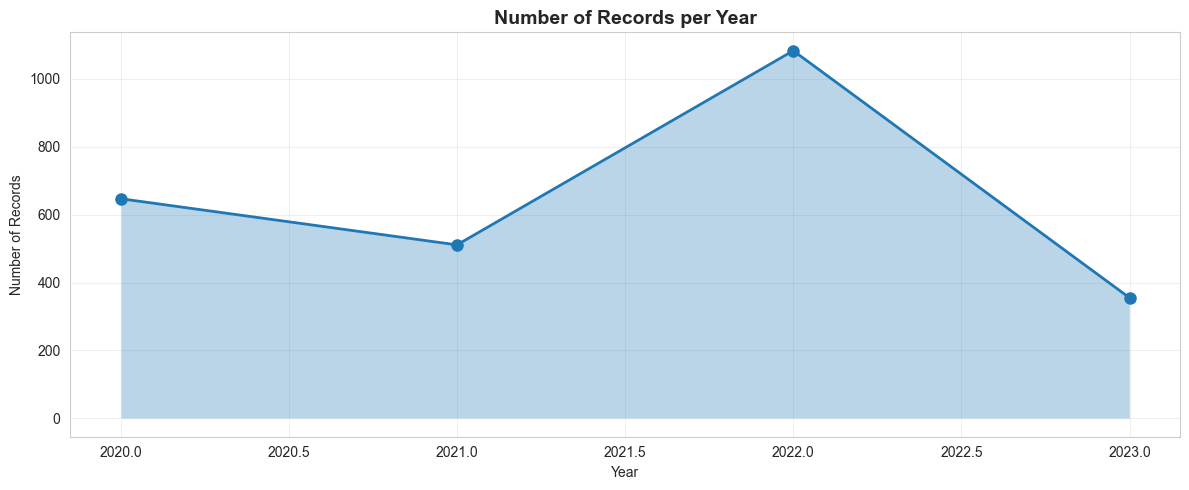


Unique Typhoons per Year:
Year
2020    5
2021    6
2022    9
2023    5
Name: Typhoon Name, dtype: int64


In [10]:
# Analyze yearly distribution
print("\n" + "=" * 80)
print("YEARLY DISTRIBUTION")
print("=" * 80)

year_counts = df['Year'].value_counts().sort_index()
print(f"\nRecords per Year:")
print(year_counts)

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=8)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.3)
plt.title('Number of Records per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Typhoons per year
typhoons_per_year = df.groupby('Year')['Typhoon Name'].nunique()
print(f"\nUnique Typhoons per Year:")
print(typhoons_per_year)

## 5. Regional Distribution


REGIONAL DISTRIBUTION

Records per Region:
Region
5    837
2    732
3    576
8    451
Name: count, dtype: int64

Top 10 Provinces by Records:
Province
CAGAYAN           386
CAMARINES SUR     279
MASBATE           200
BATANES           143
ZAMBALES          125
BULACAN           120
SOUTHERN LEYTE    117
ALBAY             114
ISABELA           112
LEYTE             107
Name: count, dtype: int64


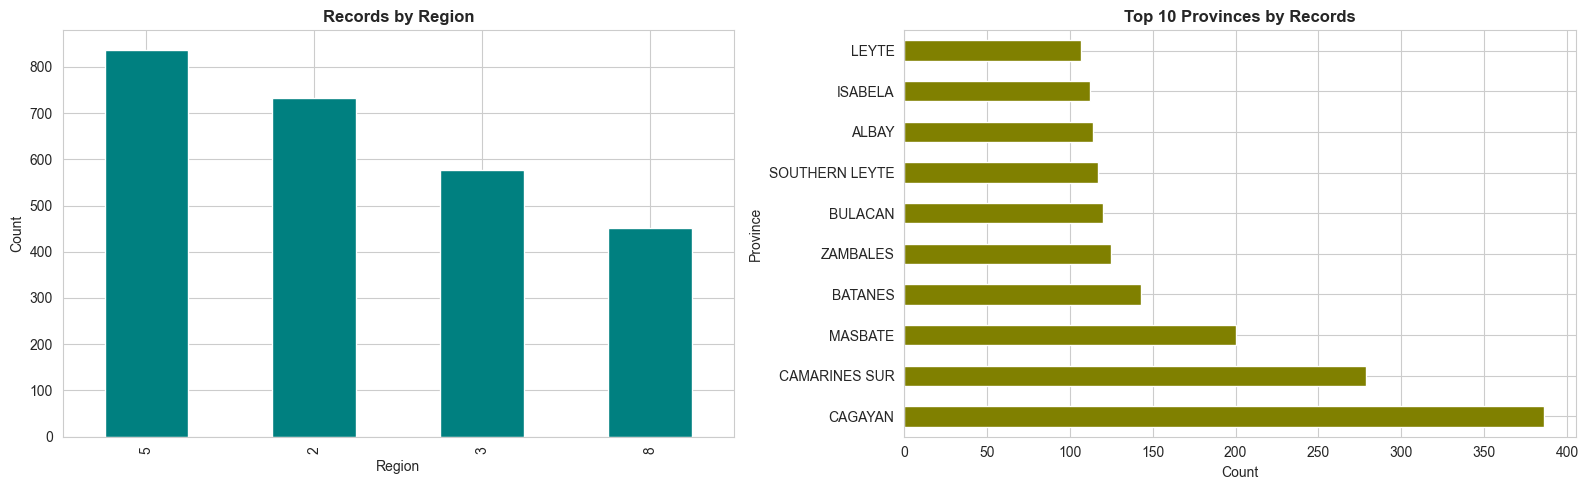

In [11]:
# Analyze regional distribution
print("\n" + "=" * 80)
print("REGIONAL DISTRIBUTION")
print("=" * 80)

region_counts = df['Region'].value_counts()
print(f"\nRecords per Region:")
print(region_counts)

province_counts = df['Province'].value_counts().head(10)
print(f"\nTop 10 Provinces by Records:")
print(province_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

region_counts.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Records by Region', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Count')

province_counts.plot(kind='barh', ax=axes[1], color='olive')
axes[1].set_title('Top 10 Provinces by Records', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Province')

plt.tight_layout()
plt.show()

## 6. Impact Variables Statistics


IMPACT VARIABLES STATISTICS

Descriptive Statistics:
           Families         Person         Dead  Injured/Ill      Missing  \
count   2596.000000    2596.000000  2596.000000  2596.000000  2596.000000   
mean    1107.063945    4241.530431     0.084746     0.234977     0.004622   
std     3231.477397   12275.538897     2.166068     2.272620     0.096058   
min        0.000000       0.000000     0.000000     0.000000     0.000000   
25%       11.000000      42.000000     0.000000     0.000000     0.000000   
50%       99.000000     357.000000     0.000000     0.000000     0.000000   
75%      644.000000    2567.000000     0.000000     0.000000     0.000000   
max    60550.000000  195016.000000    95.000000    56.000000     4.000000   

           Totally     Partially          Cost  
count  2596.000000   2596.000000  2.596000e+03  
mean     38.669877    141.243837  2.865990e+05  
std     331.595454    856.570153  1.268432e+06  
min       0.000000      0.000000  0.000000e+00  
25%    

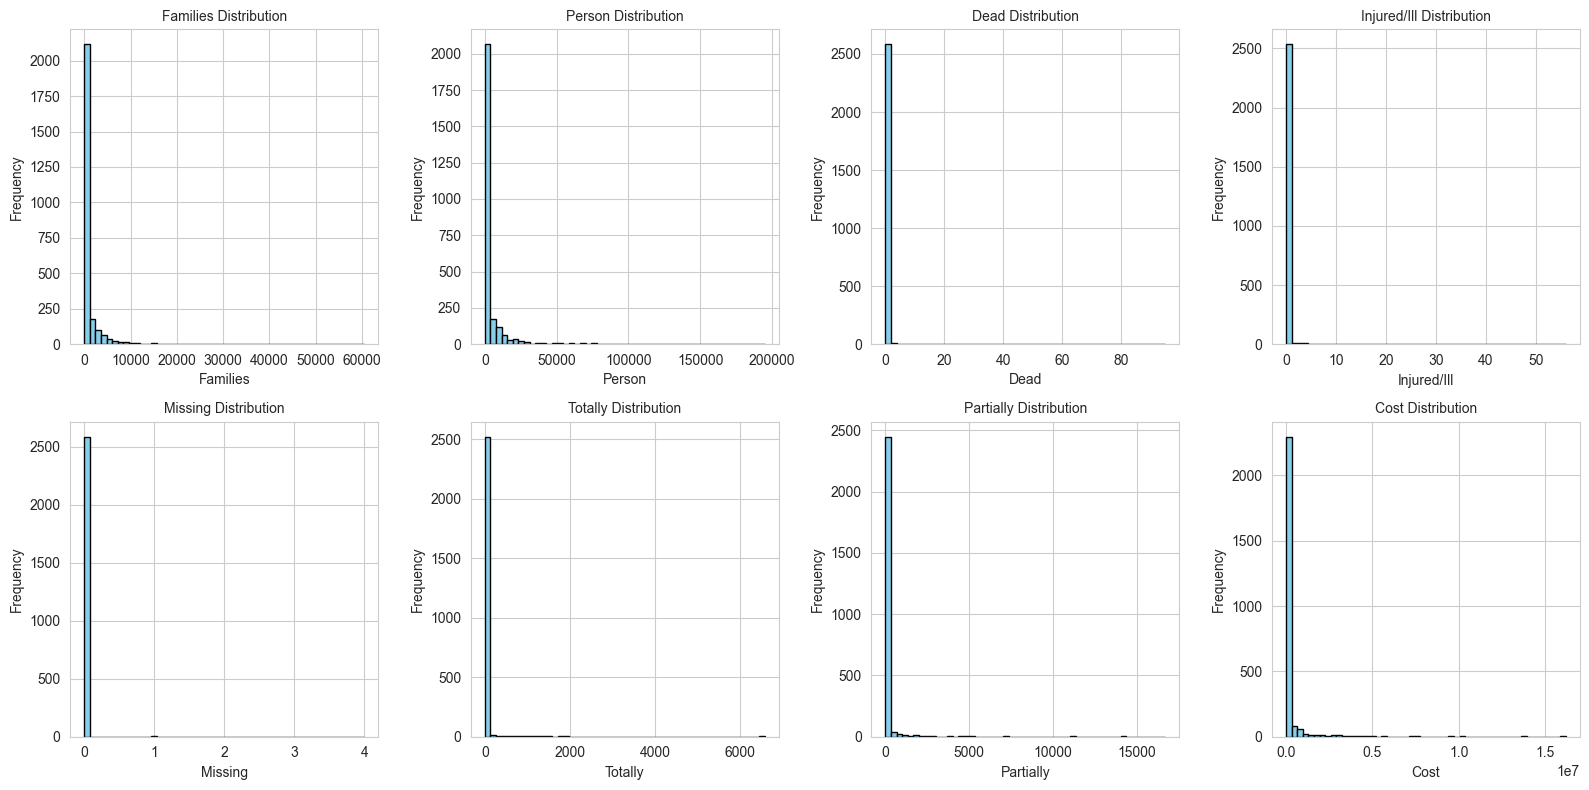

In [12]:
# Analyze impact variables
print("\n" + "=" * 80)
print("IMPACT VARIABLES STATISTICS")
print("=" * 80)

impact_cols = ['Families', 'Person', 'Dead', 'Injured/Ill', 'Missing', 'Totally', 'Partially', 'Cost']

print("\nDescriptive Statistics:")
print(df[impact_cols].describe())

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(impact_cols):
    df[col].hist(bins=50, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 7. Weather Variables Analysis


WEATHER VARIABLES STATISTICS

Descriptive Statistics:
       Max_Sustained_Wind_kph  Max_24hr_Rainfall_mm  Total_Storm_Rainfall_mm  \
count             2596.000000           2596.000000              2596.000000   
mean               129.622496            107.176221               177.969110   
std                 56.077396             74.291721               122.153349   
min                 45.000000              0.000000                 0.000000   
25%                 75.000000             53.500000                89.000000   
50%                120.000000             99.650000               155.400000   
75%                195.000000            136.200000               245.800000   
max                225.000000            510.000000               770.500000   

       Min_Pressure_hPa  Duration_in_PAR_Hours  Distance_km  
count       2596.000000            2596.000000  2596.000000  
mean         997.100539             108.125462    34.835171  
std            9.904970              4

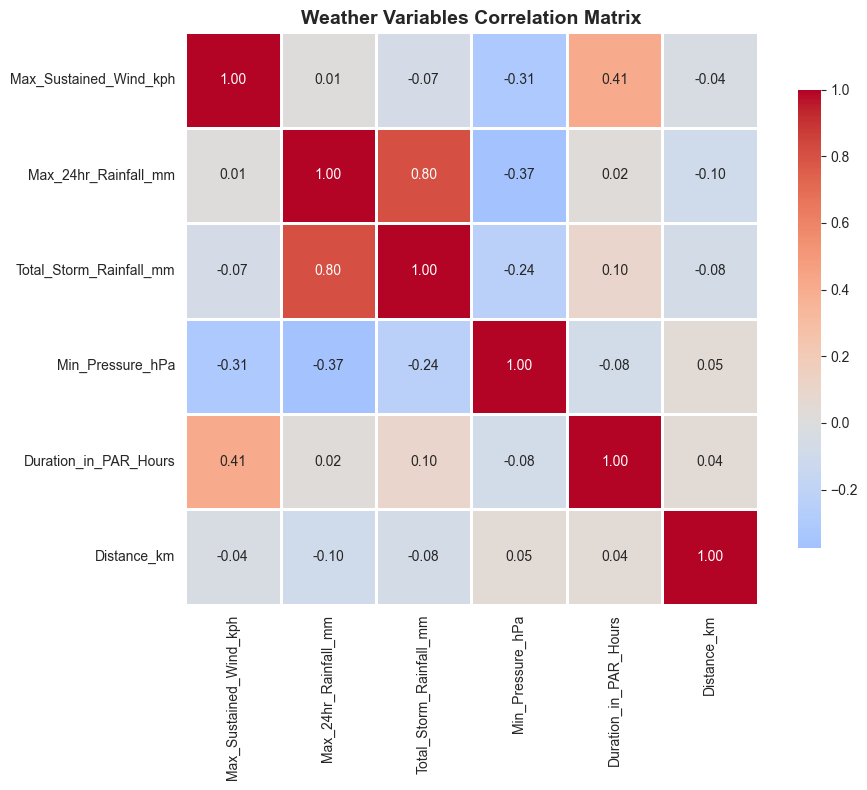

In [13]:
# Analyze weather variables
print("\n" + "=" * 80)
print("WEATHER VARIABLES STATISTICS")
print("=" * 80)

weather_cols = ['Max_Sustained_Wind_kph', 'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 
                'Min_Pressure_hPa', 'Duration_in_PAR_Hours', 'Distance_km']

print("\nDescriptive Statistics:")
print(df[weather_cols].describe())

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation = df[weather_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Report

In [14]:
# Generate comprehensive summary
print("\n" + "=" * 80)
print("COMPREHENSIVE SUMMARY REPORT")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Total Features: {df.shape[1]}")
print(f"   • Date Range: {df['Year'].min()} - {df['Year'].max()}")

print(f"\n🌀 Tropical Cyclone Information:")
print(f"   • Unique Typhoons: {df['Typhoon Name'].nunique()}")
print(f"   • Most Frequent: {typhoon_counts.index[0]} ({typhoon_counts.values[0]} records)")
print(f"   • Least Frequent: {typhoon_counts.index[-1]} ({typhoon_counts.values[-1]} records)")
print(f"   • Imbalance Ratio: {imbalance_ratio:.2f}:1")

print(f"\n🏘️ Geographic Coverage:")
print(f"   • Regions: {df['Region'].nunique()}")
print(f"   • Provinces: {df['Province'].nunique()}")
print(f"   • Cities/Municipalities: {df['City/Municipality'].nunique()}")

print(f"\n☁️ Weather Data:")
print(f"   • Weather Stations: {df['Nearest_Station'].nunique()}")
print(f"   • Records with Weather Data: {df['Weather_Records_Found'].sum():,}")
print(f"   • Coverage: {(df['Weather_Records_Found'].sum()/len(df)*100):.1f}%")

print(f"\n💀 Impact Summary:")
print(f"   • Total Deaths: {df['Dead'].sum():,}")
print(f"   • Total Affected Families: {df['Families'].sum():,}")
print(f"   • Total Affected Persons: {df['Person'].sum():,}")
print(f"   • Total Cost: ₱{df['Cost'].sum():,.2f}")

print(f"\n⚠️ Data Quality Issues:")
if info_df['Missing Count'].sum() > 0:
    print(f"   • Columns with Missing Values: {(info_df['Missing Count'] > 0).sum()}")
else:
    print(f"   • ✓ No missing values detected")

if imbalance_ratio > 3:
    print(f"   • ⚠️ Class imbalance detected ({imbalance_ratio:.2f}:1)")
else:
    print(f"   • ✓ Classes are relatively balanced")

print("\n" + "=" * 80)


COMPREHENSIVE SUMMARY REPORT

📊 Dataset Overview:
   • Total Records: 2,596
   • Total Features: 30
   • Date Range: 2020 - 2023

🌀 Tropical Cyclone Information:
   • Unique Typhoons: 25
   • Most Frequent: PAENG (413 records)
   • Least Frequent: KABAYAN (71 records)
   • Imbalance Ratio: 5.82:1

🏘️ Geographic Coverage:
   • Regions: 4
   • Provinces: 24
   • Cities/Municipalities: 442

☁️ Weather Data:
   • Weather Stations: 22
   • Records with Weather Data: 13,690
   • Coverage: 527.3%

💀 Impact Summary:
   • Total Deaths: 220
   • Total Affected Families: 2,873,938
   • Total Affected Persons: 11,011,013
   • Total Cost: ₱744,010,981.13

⚠️ Data Quality Issues:
   • ✓ No missing values detected
   • ⚠️ Class imbalance detected (5.82:1)

